# Agent 3 — Forecast Optimizer
## Pipeline: Agent 2 (Risk Detector) → **Agent 3 (Forecast Optimizer)** → Agent 4 (Replenishment)

Addresses systematic human forecasting bias. **Task A**: detects overestimation (classification). **Task B**: computes correction factor (regression).

---

## STEP 1 — INSTALL LIBRARIES

In [1]:
# Core libraries (CPU). Run once; restart the kernel afterwards if anything upgrades.
%pip install -q pandas numpy matplotlib seaborn xgboost lightgbm catboost scikit-learn imbalanced-learn shap joblib scipy pyarrow>=13.0.0

print("✅ All libraries installed")

Note: you may need to restart the kernel to use updated packages.
✅ All libraries installed



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## STEP 2 — VERIFY ENVIRONMENT

In [2]:
import platform, struct

print(f'System        : {platform.system()} {platform.release()}')
print(f'Machine       : {platform.machine()}')
print(f'Python bits   : {struct.calcsize("P") * 8}')

# ---------- GPU detection (routes XGBoost / CatBoost to CUDA when present) ----------
GPU_AVAILABLE = False
GPU_NAME      = None
try:
    import torch
    if torch.cuda.is_available():
        GPU_AVAILABLE = True
        GPU_NAME = torch.cuda.get_device_name(0)
except Exception:
    pass  # torch not installed or no CUDA build -> stay on CPU

if GPU_AVAILABLE:
    print(f'✅ CUDA GPU detected : {GPU_NAME}')
else:
    print('ℹ️  No CUDA GPU detected (or torch missing) — training on CPU')

# Per-library device settings consumed by the training cells below
XGB_DEVICE      = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_TREE_METHOD = 'hist'                          # valid for both CPU and CUDA (XGBoost 2.x)
CATBOOST_TASK   = 'GPU'  if GPU_AVAILABLE else 'CPU'
# LightGBM's default pip wheel is CPU-only (GPU needs a special OpenCL/CUDA build),
# so we keep it on CPU for portability — it is more than fast enough here.
LGBM_DEVICE     = 'cpu'

print(f'   XGBoost device   : {XGB_DEVICE}')
print(f'   CatBoost task    : {CATBOOST_TASK}')
print(f'   LightGBM device  : {LGBM_DEVICE}')

System        : Windows 11
Machine       : AMD64
Python bits   : 64
✅ CUDA GPU detected : NVIDIA GeForce RTX 4070
   XGBoost device   : cuda
   CatBoost task    : GPU
   LightGBM device  : cpu


---

## STEP 3 — IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, matthews_corrcoef,
    average_precision_score,
    mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
    root_mean_squared_error
)
from sklearn.metrics import make_scorer
from catboost import CatBoostClassifier, CatBoostRegressor
from imblearn.ensemble import BalancedRandomForestClassifier

print('\u2705 All libraries imported')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   LightGBM : {lgb.__version__}')

✅ All libraries imported
   XGBoost  : 3.3.0
   LightGBM : 4.6.0


e:\CSE499B\Project Codes\Forcast Optimizer Model\levii\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## STEP 4 — LOAD DATASET

## Config — paths & output folders
Edit the four paths below for your machine, then run every cell top-to-bottom.

In [4]:
# =============================================================
#  CONFIG — edit these paths for your machine
# =============================================================
from pathlib import Path

# Processed dataset produced upstream (Agent-2 feature table)
DATASET_PATH        = Path(r"E:\CSE499B\Project Codes\Forcast Optimizer Model\Dataset\Processed_Dataset.pkl")

# Folder holding the trained Agent-2 (backorder) models this notebook consumes
AGENT2_MODELS_DIR   = Path(r"E:\CSE499B\Project Codes\Forcast Optimizer Model\models")

# NEW output folder for this Agent-3 / Forecast-Optimizer notebook's models
FORECAST_MODELS_DIR = Path(r"E:\CSE499B\Project Codes\Forcast Optimizer Model\forecast models")

# Where figures are saved
FIG_DIR             = Path(r"E:\CSE499B\Project Codes\Forcast Optimizer Model\figures")

FORECAST_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Config ready:')
print(f'  Dataset             : {DATASET_PATH}')
print(f'  Agent-2 models dir  : {AGENT2_MODELS_DIR}')
print(f'  Forecast models →   : {FORECAST_MODELS_DIR}')
print(f'  Figures →           : {FIG_DIR}')

Config ready:
  Dataset             : E:\CSE499B\Project Codes\Forcast Optimizer Model\Dataset\Processed_Dataset.pkl
  Agent-2 models dir  : E:\CSE499B\Project Codes\Forcast Optimizer Model\models
  Forecast models →   : E:\CSE499B\Project Codes\Forcast Optimizer Model\forecast models
  Figures →           : E:\CSE499B\Project Codes\Forcast Optimizer Model\figures


In [5]:
df = pd.read_pickle(DATASET_PATH)

print(f'✅ Dataset loaded')
print(f'   Shape  : {df.shape}')
print(f'   Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nColumns: {list(df.columns)}')

✅ Dataset loaded
   Shape  : (1929935, 26)
   Memory : 229.7 MB

Columns: ['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder', 'inv_velocity', 'safety_gap', 'sales_trend', 'perf_gap']


---

## STEP 5 — LOAD AGENT 2 OUTPUT

> `Processed_Dataset.pkl` has 26 columns; Agent 2 stacking model requires 40 features.
> `create_features()` is reproduced from `classification_m2.ipynb` Step 7 to reconstruct the 15 engineered features.

In [6]:
def create_features(df):
    d = df.copy()
    d['inventory_health_net']  = (d['national_inv'] + d['in_transit_qty']) - d['sales_1_month']
    d['sales_spike_ratio']     = d['sales_1_month'] / ((d['sales_9_month'] / 9) + 0.001)
    d['months_of_stock_left']  = d['national_inv'] / (d['sales_1_month'] + 0.001)
    d['backorder_pressure']    = (d['pieces_past_due'] * (d['deck_risk'] + 1)) / (d['national_inv'] + 1)
    d['supplier_risk_score']   = d['deck_risk'] + d['oe_constraint'] + d['ppap_risk']
    d['forecast_accuracy_gap'] = abs(d['forecast_3_month'] - d['sales_3_month']) / (d['sales_3_month'] + 1)
    d['inv_depletion_rate']    = (d['sales_9_month'] - d['sales_1_month'] * 9) / (d['sales_9_month'] + 1)
    d['lead_time_volatility']  = d['lead_time'] * d['perf_gap']
    d['safety_stock_urgency']  = (d['min_bank'] - d['national_inv']) / (d['min_bank'] + 1)
    d['performance_trend']     = d['perf_6_month_avg'] - d['perf_12_month_avg']
    d['demand_forecast_ratio'] = d['forecast_3_month'] / ((d['sales_9_month'] / 9) + 0.001)
    d['transit_coverage']      = d['in_transit_qty'] / (d['sales_1_month'] + 0.001)
    d['coverage_ratio']        = (d['national_inv'] + d['in_transit_qty']) / (d['forecast_3_month'] + 1e-5)
    d['replenishment_gap']     = d['forecast_3_month'] - d['national_inv'] - d['in_transit_qty']
    d['critical_state']        = (
        (d['months_of_stock_left'] < d['lead_time']) &
        (d['safety_stock_urgency'] > 0) &
        (d['replenishment_gap'] > 0)
    ).astype(int)
    d = d.replace([np.inf, -np.inf], 0)
    return d


df_full = create_features(df)

# ---- Load Agent-2 artifacts with an actionable error if a filename differs ----
def _load_agent2(name):
    p = AGENT2_MODELS_DIR / name
    if not p.exists():
        found = "\n     ".join(sorted(f.name for f in AGENT2_MODELS_DIR.glob('*.pkl'))) or '(none)'
        raise FileNotFoundError(
            f"'{name}' not found in {AGENT2_MODELS_DIR}\n"
            f"   .pkl files present:\n     {found}"
        )
    return joblib.load(p)

agent2_model     = _load_agent2('stacking_proposed.pkl')
agent2_threshold = _load_agent2('optimal_thresholds.pkl')['stacking']
agent2_features  = _load_agent2('feature_columns.pkl')

X_agent2 = df_full[agent2_features]

agent2_proba = agent2_model.predict_proba(X_agent2)[:, 1]
agent2_preds = (agent2_proba >= agent2_threshold).astype(int)


def encode_risk_level(prob):
    if prob >= 0.80:    return 3   # CRITICAL
    elif prob >= 0.60:  return 2   # HIGH
    elif prob >= 0.35:  return 1   # MEDIUM
    else:               return 0   # LOW


df['backorder_probability'] = agent2_proba
df['alarm_triggered']       = agent2_preds
df['risk_level_encoded']    = df['backorder_probability'].apply(encode_risk_level)

print('✅ Agent 2 signals integrated')
print(f'   Alarm triggered (HIGH risk) : {agent2_preds.sum():,} rows ({agent2_preds.mean()*100:.2f}%)')
print(f'   Risk level distribution:')
print(df['risk_level_encoded'].value_counts().sort_index().rename(
    {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH', 3: 'CRITICAL'}))

✅ Agent 2 signals integrated
   Alarm triggered (HIGH risk) : 36,949 rows (1.91%)
   Risk level distribution:
risk_level_encoded
LOW         1671442
MEDIUM        78295
HIGH          63450
CRITICAL     116748
Name: count, dtype: int64


---

## STEP 6 — HUMAN BIAS ANALYSIS (EDA — Required Journal Figure)

  HUMAN PLANNER BIAS ANALYSIS
  Human MAPE (3M horizon) : 1771.60%
  Human MAPE (6M horizon) : 2927.99%
  Human MAPE (9M horizon) : 3757.38%
  % rows where human overestimated (3M): 16.3%
  Mean bias ratio (3M)    : 0.000
  (>1.0 = chronic overestimation)
  Human WMAPE (3M horizon): 58.74%
  (WMAPE is robust to sparse demand — cite in paper alongside MAPE)


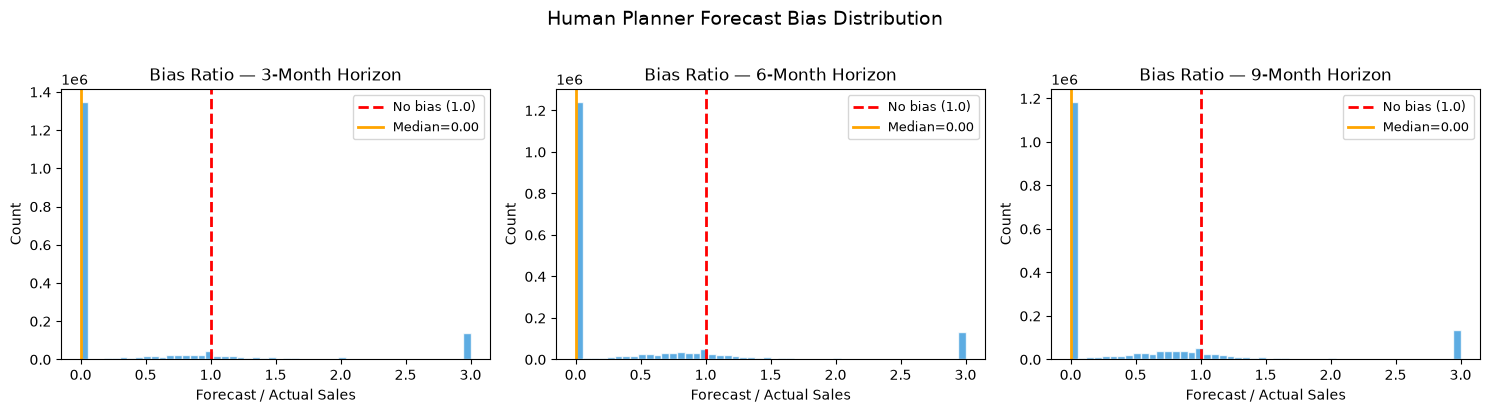

In [7]:
print('=' * 60)
print('  HUMAN PLANNER BIAS ANALYSIS')
print('=' * 60)

df['error_3m'] = df['forecast_3_month'] - df['sales_3_month']
df['error_6m'] = df['forecast_6_month'] - df['sales_6_month']
df['error_9m'] = df['forecast_9_month'] - df['sales_9_month']

df['bias_ratio_3m'] = df['forecast_3_month'] / (df['sales_3_month'] + 1e-5)
df['bias_ratio_6m'] = df['forecast_6_month'] / (df['sales_6_month'] + 1e-5)
df['bias_ratio_9m'] = df['forecast_9_month'] / (df['sales_9_month'] + 1e-5)

human_mape_3m = mean_absolute_percentage_error(
    df['sales_3_month'].clip(lower=1),
    df['forecast_3_month'].clip(lower=1)
) * 100

human_mape_6m = mean_absolute_percentage_error(
    df['sales_6_month'].clip(lower=1),
    df['forecast_6_month'].clip(lower=1)
) * 100

human_mape_9m = mean_absolute_percentage_error(
    df['sales_9_month'].clip(lower=1),
    df['forecast_9_month'].clip(lower=1)
) * 100

overestimate_pct_3m = (df['bias_ratio_3m'] > 1.0).mean() * 100

print(f'  Human MAPE (3M horizon) : {human_mape_3m:.2f}%')
print(f'  Human MAPE (6M horizon) : {human_mape_6m:.2f}%')
print(f'  Human MAPE (9M horizon) : {human_mape_9m:.2f}%')
print(f'  % rows where human overestimated (3M): {overestimate_pct_3m:.1f}%')
print(f'  Mean bias ratio (3M)    : {df["bias_ratio_3m"].median():.3f}')
print(f'  (>1.0 = chronic overestimation)')

HUMAN_MAPE_3M = human_mape_3m
HUMAN_MAPE_6M = human_mape_6m

# WMAPE — weighted, robust to zero/sparse demand SKUs
HUMAN_WMAPE_3M = (
    np.abs(df['sales_3_month'].clip(lower=1) - df['forecast_3_month'].clip(lower=1)).sum() /
    df['sales_3_month'].clip(lower=1).sum()
) * 100
print(f'  Human WMAPE (3M horizon): {HUMAN_WMAPE_3M:.2f}%')
print(f'  (WMAPE is robust to sparse demand \u2014 cite in paper alongside MAPE)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
for ax, col, label in zip(axes,
    ['bias_ratio_3m', 'bias_ratio_6m', 'bias_ratio_9m'],
    ['3-Month', '6-Month', '9-Month']):
    vals = df[col].clip(0, 3)
    ax.hist(vals, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='No bias (1.0)')
    ax.axvline(vals.median(), color='orange', linestyle='-',
               linewidth=2, label=f'Median={vals.median():.2f}')
    ax.set_title(f'Bias Ratio \u2014 {label} Horizon', fontsize=12)
    ax.set_xlabel('Forecast / Actual Sales', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Human Planner Forecast Bias Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'agent3_bias_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## STEP 7 — FEATURE ENGINEERING (Agent 3 Specific)

In [8]:
def create_agent3_features(df):
    d = df.copy()

    # F1: Bias ratio per horizon
    d['bias_ratio_3m'] = d['forecast_3_month'] / (d['sales_3_month'] + 1e-5)
    d['bias_ratio_6m'] = d['forecast_6_month'] / (d['sales_6_month'] + 1e-5)
    d['bias_ratio_9m'] = d['forecast_9_month'] / (d['sales_9_month'] + 1e-5)

    # F2: Absolute forecast error per horizon
    d['error_3m'] = d['forecast_3_month'] - d['sales_3_month']
    d['error_6m'] = d['forecast_6_month'] - d['sales_6_month']
    d['error_9m'] = d['forecast_9_month'] - d['sales_9_month']

    # F3: Bias trend
    d['bias_trend_3_to_9'] = d['bias_ratio_9m'] - d['bias_ratio_3m']

    # F4: Chronic overestimator flag
    d['chronic_overestimator'] = (
        (d['bias_ratio_3m'] > 1.10) &
        (d['bias_ratio_6m'] > 1.10) &
        (d['bias_ratio_9m'] > 1.10)
    ).astype(int)

    # F5: Forecast consistency
    d['forecast_consistency'] = d[
        ['forecast_3_month', 'forecast_6_month', 'forecast_9_month']
    ].std(axis=1) / (d['forecast_9_month'] + 1e-5)

    # F6: Sales velocity ratio
    d['sales_velocity_ratio'] = d['sales_1_month'] / (
        (d['sales_9_month'] / 9) + 1e-5
    )

    # F7: Demand volatility
    d['demand_volatility'] = d[
        ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month']
    ].std(axis=1) / (d['sales_9_month'] + 1e-5)

    # F8: Sales momentum
    d['sales_momentum'] = (
        d['sales_1_month'] - (d['sales_3_month'] / 3)
    ) / (d['sales_3_month'] / 3 + 1e-5)

    # F9: Risk-weighted bias (Agent 2 integration)
    d['risk_adjusted_bias'] = d['bias_ratio_3m'] * (
        1 - d['backorder_probability']
    )

    # F10: Risk-suppression flag
    d['correction_suppressed'] = d['alarm_triggered'].astype(int)

    # F11: Inventory coverage relative to forecast
    d['inv_vs_forecast'] = (
        d['national_inv'] + d['in_transit_qty']
    ) / (d['forecast_3_month'] + 1e-5)

    # F12: Supplier performance interaction
    d['supplier_forecast_stress'] = (
        (1 - d['perf_6_month_avg'].clip(0, 1)) * d['bias_ratio_3m']
    )

    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.fillna(d.median(numeric_only=True))

    return d


df_agent3 = create_agent3_features(df)

print(f'\u2705 Agent 3 feature engineering complete')
print(f'   Shape before : {df.shape}')
print(f'   Shape after  : {df_agent3.shape}')
print(f'   New features : {df_agent3.shape[1] - df.shape[1]}')

✅ Agent 3 feature engineering complete
   Shape before : (1929935, 35)
   Shape after  : (1929935, 45)
   New features : 10


---

## STEP 8 — DEFINE TARGETS FOR BOTH TASKS

In [9]:
# Task A: Bias Detection (Classification)
OVERESTIMATE_THRESHOLD = 1.15

df_agent3['is_overestimating'] = (
    df_agent3['bias_ratio_3m'] > OVERESTIMATE_THRESHOLD
).astype(int)

task_a_counts = Counter(df_agent3['is_overestimating'])
task_a_ir = task_a_counts[0] / task_a_counts[1] if task_a_counts[1] > 0 else 0

print('Task A \u2014 Bias Detection Target:')
print(f'  Not overestimating (0) : {task_a_counts[0]:,}  ({task_a_counts[0]/len(df_agent3)*100:.1f}%)')
print(f'  Overestimating     (1) : {task_a_counts[1]:,}  ({task_a_counts[1]/len(df_agent3)*100:.1f}%)')
print(f'  Imbalance Ratio        : {task_a_ir:.1f}:1')

# Task B: Correction Factor (Regression)
df_agent3['correction_factor'] = (
    df_agent3['sales_3_month'] / (df_agent3['forecast_3_month'] + 1e-5)
).clip(0.3, 1.5)

df_agent3['adjusted_forecast_3m'] = (
    df_agent3['forecast_3_month'] * df_agent3['correction_factor']
)

print('\nTask B \u2014 Correction Factor Stats:')
print(df_agent3['correction_factor'].describe().round(4))
print(f'\n  correction_factor < 1.0 (reduce plan) : {(df_agent3["correction_factor"] < 1.0).sum():,}')
print(f'  correction_factor = 1.0 (keep plan)   : {(df_agent3["correction_factor"] == 1.0).sum():,}')
print(f'  correction_factor > 1.0 (increase)    : {(df_agent3["correction_factor"] > 1.0).sum():,}')

Task A — Bias Detection Target:
  Not overestimating (0) : 1,657,904  (85.9%)
  Overestimating     (1) : 272,031  (14.1%)
  Imbalance Ratio        : 6.1:1

Task B — Correction Factor Stats:
count    1.929935e+06
mean     8.386000e-01
std      5.553000e-01
min      3.000000e-01
25%      3.000000e-01
50%      6.364000e-01
75%      1.500000e+00
max      1.500000e+00
Name: correction_factor, dtype: float64

  correction_factor < 1.0 (reduce plan) : 1,115,846
  correction_factor = 1.0 (keep plan)   : 179
  correction_factor > 1.0 (increase)    : 813,910


---

## STEP 9 — DEFINE FEATURES AND SPLIT

In [10]:
EXCLUDE_COLS = [
    'went_on_backorder',
    'is_overestimating',
    'correction_factor',
    'adjusted_forecast_3m',
    'error_3m', 'error_6m', 'error_9m',
    # Leakage: these directly encode both targets
    'bias_ratio_3m', 'bias_ratio_6m', 'bias_ratio_9m',
    'chronic_overestimator', 'bias_trend_3_to_9',
    'risk_adjusted_bias', 'supplier_forecast_stress',
    # --- LEAKAGE FIX -------------------------------------------------------
    # Targets = f(sales_3_month, forecast_3_month). sales_3_month is the actual
    # demand the forecast is corrected toward, so it (and the longer sales
    # windows that reconstruct it) must NEVER be a feature. The forecast_*
    # columns stay: the human forecast is genuinely known at inference time.
    'sales_3_month', 'sales_6_month', 'sales_9_month',
    'demand_volatility',     # = std(sales_1,3,6,9)/sales_9  -> contains sales_3
    'sales_momentum',        # = f(sales_1, sales_3)         -> contains sales_3
    'sales_velocity_ratio',  # = sales_1/(sales_9/9)         -> sales_9 proxy
    # ----------------------------------------------------------------------
]

FEATURE_COLS = [c for c in df_agent3.columns if c not in EXCLUDE_COLS]
# Keep only numeric features — string/object cols (e.g. sku, product_id) crash the boosters
FEATURE_COLS = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(df_agent3[c])]

X  = df_agent3[FEATURE_COLS]
yA = df_agent3['is_overestimating']
yB = df_agent3['correction_factor']

print(f'Features       : {X.shape[1]}')
print(f'Task A target  : {yA.name} \u2014 {yA.value_counts().to_dict()}')
print(f'Task B target  : {yB.name} \u2014 mean={yB.mean():.3f}, std={yB.std():.3f}')

X = X.fillna(X.median(numeric_only=True))
print(f'NaN in X       : {X.isnull().sum().sum()}')

X_train, X_temp, yA_train, yA_temp, yB_train, yB_temp = train_test_split(
    X, yA, yB, test_size=0.20, stratify=yA, random_state=42
)

X_val, X_test, yA_val, yA_test, yB_val, yB_test = train_test_split(
    X_temp, yA_temp, yB_temp,
    test_size=0.50, stratify=yA_temp, random_state=42
)

print('\n\u2705 Split complete:')
print(f'  Train : {len(X_train):,}  | Overestimating: {yA_train.mean()*100:.1f}%')
print(f'  Val   : {len(X_val):,}   | Overestimating: {yA_val.mean()*100:.1f}%')
print(f'  Test  : {len(X_test):,}   | Overestimating: {yA_test.mean()*100:.1f}%')

SCALE_POS_WEIGHT_A = (yA_train == 0).sum() / (yA_train == 1).sum()
print(f'\nTask A Imbalance Ratio : {SCALE_POS_WEIGHT_A:.1f}:1')
print(f'scale_pos_weight       : {SCALE_POS_WEIGHT_A:.1f}')

Features       : 28
Task A target  : is_overestimating — {0: 1657904, 1: 272031}
Task B target  : correction_factor — mean=0.839, std=0.555
NaN in X       : 0

✅ Split complete:
  Train : 1,543,948  | Overestimating: 14.1%
  Val   : 192,993   | Overestimating: 14.1%
  Test  : 192,994   | Overestimating: 14.1%

Task A Imbalance Ratio : 6.1:1
scale_pos_weight       : 6.1


---

## STEP 10 — TASK A: BIAS DETECTOR (Classification)

In [11]:
print('Training Task A \u2014 Bias Detector models...')

thresholds_a = np.arange(0.01, 0.99, 0.005)

# Model A1: LightGBM
lgb_a = lgb.LGBMClassifier(
    n_estimators  = 500,
    is_unbalance  = True,
    max_depth     = 6,
    learning_rate = 0.05,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = -1
)
lgb_a.fit(X_train, yA_train,
          eval_set=[(X_val, yA_val)],
          callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_a_probs = lgb_a.predict_proba(X_val)[:, 1]
lgb_a_auc   = roc_auc_score(yA_val, lgb_a_probs)
lgb_a_pr    = average_precision_score(yA_val, lgb_a_probs)

lgb_a_f1s    = [f1_score(yA_val, (lgb_a_probs >= t).astype(int),
                         zero_division=0) for t in thresholds_a]
best_t_lgb_a = thresholds_a[np.argmax(lgb_a_f1s)]
lgb_a_preds  = (lgb_a_probs >= best_t_lgb_a).astype(int)

print(f'\n  LightGBM (Task A):')
print(f'  Threshold  : {best_t_lgb_a:.3f}')
print(f'  F1-Score   : {f1_score(yA_val, lgb_a_preds, zero_division=0):.4f}')
print(f'  Precision  : {precision_score(yA_val, lgb_a_preds, zero_division=0):.4f}')
print(f'  Recall     : {recall_score(yA_val, lgb_a_preds, zero_division=0):.4f}')
print(f'  MCC        : {matthews_corrcoef(yA_val, lgb_a_preds):.4f}')
print(f'  ROC-AUC    : {lgb_a_auc:.4f}')
print(f'  PR-AUC     : {lgb_a_pr:.4f}')

# Model A2: CatBoost  (GPU if available, auto-fallback to CPU)
def _make_cat_a(task):
    return CatBoostClassifier(
        iterations         = 500,
        auto_class_weights = 'Balanced',
        learning_rate      = 0.05,
        depth              = 6,
        eval_metric        = 'F1',
        random_seed        = 42,
        task_type          = task,
        verbose            = 100
    )

cat_a = _make_cat_a(CATBOOST_TASK)
try:
    cat_a.fit(X_train, yA_train, eval_set=(X_val, yA_val), early_stopping_rounds=50)
except Exception as e:
    print(f'⚠️  CatBoost Task-A GPU fit failed ({type(e).__name__}: {e}); retraining on CPU...')
    cat_a = _make_cat_a('CPU')
    cat_a.fit(X_train, yA_train, eval_set=(X_val, yA_val), early_stopping_rounds=50)

cat_a_probs = cat_a.predict_proba(X_val)[:, 1]
cat_a_auc   = roc_auc_score(yA_val, cat_a_probs)
cat_a_pr    = average_precision_score(yA_val, cat_a_probs)

cat_a_f1s    = [f1_score(yA_val, (cat_a_probs >= t).astype(int),
                         zero_division=0) for t in thresholds_a]
best_t_cat_a = thresholds_a[np.argmax(cat_a_f1s)]
cat_a_preds  = (cat_a_probs >= best_t_cat_a).astype(int)

print(f'\n  CatBoost (Task A):')
print(f'  Threshold  : {best_t_cat_a:.3f}')
print(f'  F1-Score   : {f1_score(yA_val, cat_a_preds, zero_division=0):.4f}')
print(f'  MCC        : {matthews_corrcoef(yA_val, cat_a_preds):.4f}')
print(f'  ROC-AUC    : {cat_a_auc:.4f}')
print(f'  PR-AUC     : {cat_a_pr:.4f}')

# Model A3: BalancedRandomForest
brf_a = BalancedRandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    n_jobs       = -1
)
brf_a.fit(X_train, yA_train)

brf_a_probs = brf_a.predict_proba(X_val)[:, 1]
brf_a_auc   = roc_auc_score(yA_val, brf_a_probs)
brf_a_pr    = average_precision_score(yA_val, brf_a_probs)

brf_a_f1s    = [f1_score(yA_val, (brf_a_probs >= t).astype(int),
                         zero_division=0) for t in thresholds_a]
best_t_brf_a = thresholds_a[np.argmax(brf_a_f1s)]
brf_a_preds  = (brf_a_probs >= best_t_brf_a).astype(int)

print(f'\n  BalancedRandomForest (Task A):')
print(f'  Threshold  : {best_t_brf_a:.3f}')
print(f'  F1-Score   : {f1_score(yA_val, brf_a_preds, zero_division=0):.4f}')
print(f'  MCC        : {matthews_corrcoef(yA_val, brf_a_preds):.4f}')
print(f'  ROC-AUC    : {brf_a_auc:.4f}')
print(f'  PR-AUC     : {brf_a_pr:.4f}')

Training Task A — Bias Detector models...

  LightGBM (Task A):
  Threshold  : 0.765
  F1-Score   : 0.9545
  Precision  : 0.9400
  Recall     : 0.9694
  MCC        : 0.9470
  ROC-AUC    : 0.9986
  PR-AUC     : 0.9909
0:	learn: 0.9407723	test: 0.9402175	best: 0.9402175 (0)	total: 542ms	remaining: 4m 30s
100:	learn: 0.9611123	test: 0.9610010	best: 0.9610010 (100)	total: 1.52s	remaining: 6s
200:	learn: 0.9695401	test: 0.9690103	best: 0.9690103 (200)	total: 2.48s	remaining: 3.68s
300:	learn: 0.9737031	test: 0.9731960	best: 0.9732556 (299)	total: 3.45s	remaining: 2.28s
400:	learn: 0.9766359	test: 0.9762804	best: 0.9762833 (397)	total: 4.42s	remaining: 1.09s
499:	learn: 0.9785500	test: 0.9780418	best: 0.9780418 (499)	total: 5.37s	remaining: 0us
bestTest = 0.9780418162
bestIteration = 499

  CatBoost (Task A):
  Threshold  : 0.780
  F1-Score   : 0.9365
  MCC        : 0.9260
  ROC-AUC    : 0.9975
  PR-AUC     : 0.9839

  BalancedRandomForest (Task A):
  Threshold  : 0.715
  F1-Score   : 0.9304

---

## STEP 11 — TASK B: CORRECTION REGRESSOR

In [12]:
print('Training Task B \u2014 Correction Regressor models...')

# Model B1: XGBoost Regressor  (GPU if available, auto-fallback to CPU)
def _make_xgb_b(device):
    return xgb.XGBRegressor(
        n_estimators          = 1000,
        max_depth             = 6,
        learning_rate         = 0.01,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 5,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        tree_method           = XGB_TREE_METHOD,
        device                = device,
        early_stopping_rounds = 50,
        eval_metric           = 'mae',
        random_state          = 42,
        n_jobs                = -1
    )

xgb_b = _make_xgb_b(XGB_DEVICE)
try:
    xgb_b.fit(X_train, yB_train, eval_set=[(X_val, yB_val)], verbose=100)
except Exception as e:
    print(f'⚠️  XGBoost GPU fit failed ({type(e).__name__}: {e}); retraining on CPU...')
    xgb_b = _make_xgb_b('cpu')
    xgb_b.fit(X_train, yB_train, eval_set=[(X_val, yB_val)], verbose=100)

xgb_b_preds = xgb_b.predict(X_val)

print(f'\n  XGBoost (Task B):')
print(f'  MAE        : {mean_absolute_error(yB_val, xgb_b_preds):.4f}')
print(f'  RMSE       : {root_mean_squared_error(yB_val, xgb_b_preds):.4f}')
print(f'  R\u00b2         : {r2_score(yB_val, xgb_b_preds):.4f}')

# Model B2: LightGBM Regressor
lgb_b = lgb.LGBMRegressor(
    n_estimators  = 1000,
    max_depth     = 6,
    learning_rate = 0.01,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = -1
)
lgb_b.fit(X_train, yB_train,
          eval_set=[(X_val, yB_val)],
          callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_b_preds = lgb_b.predict(X_val)

print(f'\n  LightGBM (Task B):')
print(f'  MAE        : {mean_absolute_error(yB_val, lgb_b_preds):.4f}')
print(f'  RMSE       : {root_mean_squared_error(yB_val, lgb_b_preds):.4f}')
print(f'  R\u00b2         : {r2_score(yB_val, lgb_b_preds):.4f}')

# Model B3: CatBoost Regressor  (GPU if available, auto-fallback to CPU)
def _make_cat_b(task):
    return CatBoostRegressor(
        iterations    = 500,
        learning_rate = 0.05,
        depth         = 6,
        eval_metric   = 'MAE',
        random_seed   = 42,
        task_type     = task,
        verbose       = 100
    )

cat_b = _make_cat_b(CATBOOST_TASK)
try:
    cat_b.fit(X_train, yB_train, eval_set=(X_val, yB_val), early_stopping_rounds=50)
except Exception as e:
    print(f'⚠️  CatBoost Task-B GPU fit failed ({type(e).__name__}: {e}); retraining on CPU...')
    cat_b = _make_cat_b('CPU')
    cat_b.fit(X_train, yB_train, eval_set=(X_val, yB_val), early_stopping_rounds=50)

cat_b_preds = cat_b.predict(X_val)

print(f'\n  CatBoost (Task B):')
print(f'  MAE        : {mean_absolute_error(yB_val, cat_b_preds):.4f}')
print(f'  RMSE       : {root_mean_squared_error(yB_val, cat_b_preds):.4f}')
print(f'  R\u00b2         : {r2_score(yB_val, cat_b_preds):.4f}')

Training Task B — Correction Regressor models...
[0]	validation_0-mae:0.52892
[100]	validation_0-mae:0.30990
[200]	validation_0-mae:0.22589
[300]	validation_0-mae:0.19103
[400]	validation_0-mae:0.17570
[500]	validation_0-mae:0.16990
[600]	validation_0-mae:0.16747
[700]	validation_0-mae:0.16566
[800]	validation_0-mae:0.16419
[900]	validation_0-mae:0.16295
[999]	validation_0-mae:0.16177

  XGBoost (Task B):
  MAE        : 0.1618
  RMSE       : 0.2840
  R²         : 0.7384

  LightGBM (Task B):
  MAE        : 0.1664
  RMSE       : 0.2884
  R²         : 0.7302


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.5161179	test: 0.5159806	best: 0.5159806 (0)	total: 33.5ms	remaining: 16.7s
100:	learn: 0.1943035	test: 0.1947168	best: 0.1947168 (100)	total: 735ms	remaining: 2.9s
200:	learn: 0.1831613	test: 0.1836362	best: 0.1836362 (200)	total: 1.41s	remaining: 2.1s
300:	learn: 0.1767273	test: 0.1771969	best: 0.1771969 (300)	total: 2.07s	remaining: 1.37s
400:	learn: 0.1722252	test: 0.1726939	best: 0.1726939 (400)	total: 2.76s	remaining: 681ms
499:	learn: 0.1687134	test: 0.1691911	best: 0.1691911 (499)	total: 3.42s	remaining: 0us
bestTest = 0.1691911166
bestIteration = 499

  CatBoost (Task B):
  MAE        : 0.1692
  RMSE       : 0.2887
  R²         : 0.7295


---

## MODEL COMPARISON — SELECT BEST TASK A AND TASK B MODELS

> Required for Q1: justify model selection before final test evaluation.

In [13]:
# Task A — Validation Performance Summary
task_a_data = {
    'LightGBM'   : {
        'F1'     : f1_score(yA_val, lgb_a_preds, zero_division=0),
        'MCC'    : matthews_corrcoef(yA_val, lgb_a_preds),
        'ROC-AUC': lgb_a_auc,
        'PR-AUC' : lgb_a_pr,
    },
    'CatBoost'   : {
        'F1'     : f1_score(yA_val, cat_a_preds, zero_division=0),
        'MCC'    : matthews_corrcoef(yA_val, cat_a_preds),
        'ROC-AUC': cat_a_auc,
        'PR-AUC' : cat_a_pr,
    },
    'BalancedRF' : {
        'F1'     : f1_score(yA_val, brf_a_preds, zero_division=0),
        'MCC'    : matthews_corrcoef(yA_val, brf_a_preds),
        'ROC-AUC': brf_a_auc,
        'PR-AUC' : brf_a_pr,
    },
}

df_cmp_a = pd.DataFrame(task_a_data).T.round(4)
df_cmp_a.index.name = 'Model'

print('=' * 60)
print('  TASK A — BIAS DETECTOR: VALIDATION COMPARISON')
print('=' * 60)
print(df_cmp_a.to_string())

best_a = df_cmp_a['F1'].idxmax()
print(f'\n  → Selected for final test: {best_a} (highest F1 on val set)')

# Task B — Validation Performance Summary
task_b_data = {
    'XGBoost' : {
        'MAE' : mean_absolute_error(yB_val, xgb_b_preds),
        'RMSE': root_mean_squared_error(yB_val, xgb_b_preds),
        'R²'  : r2_score(yB_val, xgb_b_preds),
    },
    'LightGBM': {
        'MAE' : mean_absolute_error(yB_val, lgb_b_preds),
        'RMSE': root_mean_squared_error(yB_val, lgb_b_preds),
        'R²'  : r2_score(yB_val, lgb_b_preds),
    },
    'CatBoost': {
        'MAE' : mean_absolute_error(yB_val, cat_b_preds),
        'RMSE': root_mean_squared_error(yB_val, cat_b_preds),
        'R²'  : r2_score(yB_val, cat_b_preds),
    },
}

df_cmp_b = pd.DataFrame(task_b_data).T.round(4)
df_cmp_b.index.name = 'Model'

print('\n' + '=' * 60)
print('  TASK B — CORRECTION REGRESSOR: VALIDATION COMPARISON')
print('=' * 60)
print(df_cmp_b.to_string())

best_b = df_cmp_b['MAE'].idxmin()
print(f'\n  \u2192 Selected for final test: {best_b} (lowest MAE on val set)')

# Expose selected models for Step 15
model_a_map     = {'LightGBM': lgb_a, 'CatBoost': cat_a, 'BalancedRF': brf_a}
threshold_a_map = {'LightGBM': best_t_lgb_a, 'CatBoost': best_t_cat_a, 'BalancedRF': best_t_brf_a}
final_model_a     = model_a_map[best_a]
final_threshold_a = threshold_a_map[best_a]

model_b_map   = {'XGBoost': xgb_b, 'LightGBM': lgb_b, 'CatBoost': cat_b}
final_model_b = model_b_map[best_b]
print(f'\n  Task A final: {best_a}  (threshold={final_threshold_a:.3f})')
print(f'  Task B final: {best_b}')

  TASK A — BIAS DETECTOR: VALIDATION COMPARISON
                F1     MCC  ROC-AUC  PR-AUC
Model                                      
LightGBM    0.9545  0.9470   0.9986  0.9909
CatBoost    0.9365  0.9260   0.9975  0.9839
BalancedRF  0.9304  0.9189   0.9973  0.9842

  → Selected for final test: LightGBM (highest F1 on val set)

  TASK B — CORRECTION REGRESSOR: VALIDATION COMPARISON
             MAE    RMSE      R²
Model                           
XGBoost   0.1618  0.2840  0.7384
LightGBM  0.1664  0.2884  0.7302
CatBoost  0.1692  0.2887  0.7295

  → Selected for final test: XGBoost (lowest MAE on val set)

  Task A final: LightGBM  (threshold=0.765)
  Task B final: XGBoost


---

## TASK B RESIDUAL ANALYSIS (Required Journal Figure)

> Predicted vs. Actual and residual distribution for the correction regressor.

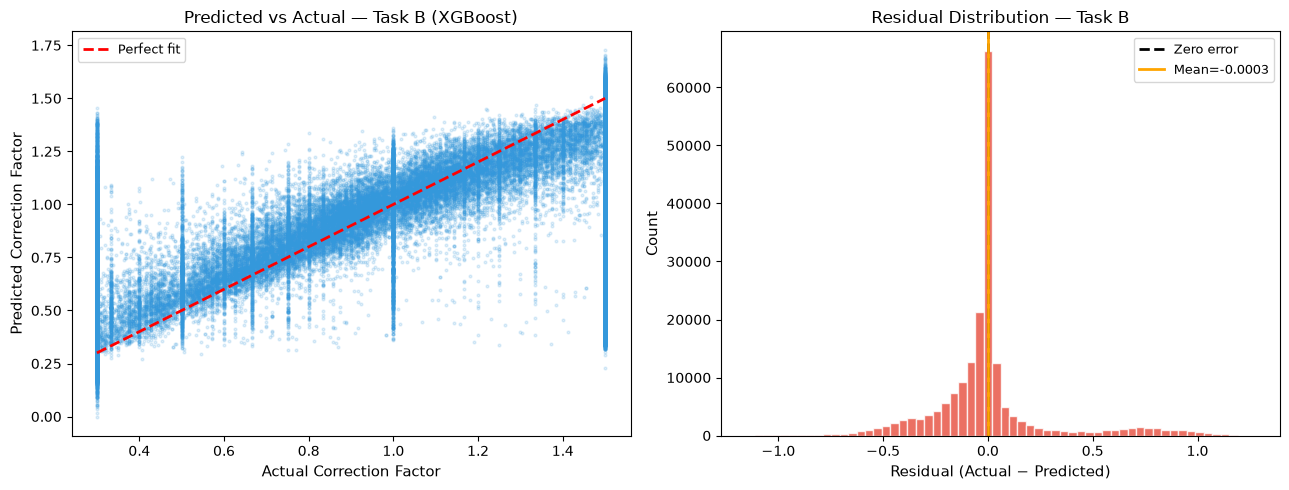

Task B — Residual Summary:
  Mean residual : -0.0003  (near 0 = unbiased predictor)
  Std residual  : 0.2840
  Max error     : 1.2724
  Min error     : -1.1521
  Saved         : E:\CSE499B\Project Codes\Forcast Optimizer Model\figures\agent3_residual_analysis.png


In [14]:
final_b_val_preds = final_model_b.predict(X_val)
residuals = yB_val.values - final_b_val_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)

# Plot 1: Predicted vs Actual
ax1 = axes[0]
ax1.scatter(yB_val, final_b_val_preds, alpha=0.15, s=4, color='#3498db')
lo, hi = yB_val.min(), yB_val.max()
ax1.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')
ax1.set_xlabel('Actual Correction Factor', fontsize=11)
ax1.set_ylabel('Predicted Correction Factor', fontsize=11)
ax1.set_title(f'Predicted vs Actual — Task B ({best_b})', fontsize=12)
ax1.legend(fontsize=9)

# Plot 2: Residual distribution
ax2 = axes[1]
ax2.hist(residuals, bins=60, color='#e74c3c', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero error')
ax2.axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2,
            label=f'Mean={residuals.mean():.4f}')
ax2.set_xlabel('Residual (Actual − Predicted)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Residual Distribution — Task B', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'agent3_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Task B — Residual Summary:')
print(f'  Mean residual : {residuals.mean():.4f}  (near 0 = unbiased predictor)')
print(f'  Std residual  : {residuals.std():.4f}')
print(f'  Max error     : {residuals.max():.4f}')
print(f'  Min error     : {residuals.min():.4f}')
print(f'  Saved         : {FIG_DIR / "agent3_residual_analysis.png"}')

---

## STEP 12 — BUSINESS METRIC: MAPE IMPROVEMENT

In [15]:
print('=' * 65)
print('  AGENT 3 BUSINESS IMPACT \u2014 MAPE IMPROVEMENT')
print('=' * 65)


def compute_mape_improvement(model_b, X_set, df_set, label):
    correction = model_b.predict(X_set).clip(0.3, 1.5)

    if 'correction_suppressed' in df_set.columns:
        correction = np.where(
            df_set['correction_suppressed'].values == 1,
            1.0,
            correction
        )

    adjusted_forecast = df_set['forecast_3_month'].values * correction
    actual_sales      = df_set['sales_3_month'].clip(lower=1).values

    human_mape = mean_absolute_percentage_error(
        actual_sales,
        df_set['forecast_3_month'].clip(lower=1).values
    ) * 100

    agent3_mape = mean_absolute_percentage_error(
        actual_sales,
        adjusted_forecast.clip(min=1)
    ) * 100

    improvement     = human_mape - agent3_mape
    improvement_pct = (improvement / human_mape) * 100

    # WMAPE — weighted, robust to zero/sparse demand
    total_actual  = actual_sales.sum()
    human_wmape   = (np.abs(actual_sales -
                     df_set['forecast_3_month'].clip(lower=1).values).sum()
                     / total_actual) * 100
    agent3_wmape  = (np.abs(actual_sales -
                     adjusted_forecast.clip(min=1)).sum()
                     / total_actual) * 100
    wmape_improv  = (human_wmape - agent3_wmape) / human_wmape * 100

    print(f'\n  [{label}]')
    print(f'  Human  MAPE   : {human_mape:.2f}%    Human  WMAPE : {human_wmape:.2f}%')
    print(f'  Agent3 MAPE   : {agent3_mape:.2f}%    Agent3 WMAPE : {agent3_wmape:.2f}%')
    print(f'  MAPE  Improv  : {improvement_pct:.1f}% relative')
    print(f'  WMAPE Improv  : {wmape_improv:.1f}% relative  \u2190 cite in paper (robust metric)')

    return human_mape, agent3_mape, improvement


h_mape, a_mape, impr = compute_mape_improvement(
    lgb_b, X_val, df_agent3.loc[X_val.index], 'LightGBM \u2014 Val Set'
)
compute_mape_improvement(xgb_b, X_val, df_agent3.loc[X_val.index], 'XGBoost \u2014 Val Set')
compute_mape_improvement(cat_b, X_val, df_agent3.loc[X_val.index], 'CatBoost \u2014 Val Set')

print('=' * 65)

  AGENT 3 BUSINESS IMPACT — MAPE IMPROVEMENT

  [LightGBM — Val Set]
  Human  MAPE   : 1394.51%    Human  WMAPE : 60.05%
  Agent3 MAPE   : 518.69%    Agent3 WMAPE : 39.48%
  MAPE  Improv  : 62.8% relative
  WMAPE Improv  : 34.3% relative  ← cite in paper (robust metric)

  [XGBoost — Val Set]
  Human  MAPE   : 1394.51%    Human  WMAPE : 60.05%
  Agent3 MAPE   : 515.38%    Agent3 WMAPE : 39.19%
  MAPE  Improv  : 63.0% relative
  WMAPE Improv  : 34.7% relative  ← cite in paper (robust metric)

  [CatBoost — Val Set]
  Human  MAPE   : 1394.51%    Human  WMAPE : 60.05%
  Agent3 MAPE   : 517.59%    Agent3 WMAPE : 40.25%
  MAPE  Improv  : 62.9% relative
  WMAPE Improv  : 33.0% relative  ← cite in paper (robust metric)


---

## STEP 13 — CROSS VALIDATION

In [16]:
print('Running 5-Fold CV for Task A (Bias Detector)...')

f1_scorer  = make_scorer(f1_score, zero_division=0)
mcc_scorer = make_scorer(matthews_corrcoef)

scoring_a = {
    'f1'      : f1_scorer,
    'mcc'     : mcc_scorer,
    'roc_auc' : 'roc_auc',
    'pr_auc'  : 'average_precision',
}

cv_a = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_a = cross_validate(
    lgb_a, X_train, yA_train,
    cv=cv_a, scoring=scoring_a,
    return_train_score=False, n_jobs=-1
)

print('\nTask A \u2014 LightGBM Bias Detector (5-Fold CV):')
for metric in scoring_a.keys():
    vals = cv_results_a[f'test_{metric}']
    print(f'  {metric:<12}: {vals.mean():.4f} \u00b1 {vals.std():.4f}')

print('\nRunning 5-Fold CV for Task B (Correction Regressor)...')

scoring_b = {
    'mae'  : make_scorer(mean_absolute_error, greater_is_better=False),
    'rmse' : make_scorer(root_mean_squared_error, greater_is_better=False),
    'r2'   : 'r2',
}

cv_b = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_b = cross_validate(
    lgb_b, X_train, yB_train,
    cv=cv_b, scoring=scoring_b,
    return_train_score=False, n_jobs=-1
)

print('\nTask B \u2014 LightGBM Correction Regressor (5-Fold CV):')
for metric in scoring_b.keys():
    vals = cv_results_b[f'test_{metric}']
    print(f'  {metric:<12}: {abs(vals.mean()):.4f} \u00b1 {vals.std():.4f}')

Running 5-Fold CV for Task A (Bias Detector)...

Task A — LightGBM Bias Detector (5-Fold CV):
  f1          : 0.9194 ± 0.0008
  mcc         : 0.9087 ± 0.0009
  roc_auc     : 0.9985 ± 0.0001
  pr_auc      : 0.9905 ± 0.0004

Running 5-Fold CV for Task B (Correction Regressor)...

Task B — LightGBM Correction Regressor (5-Fold CV):
  mae         : 0.1660 ± 0.0005
  rmse        : 0.2877 ± 0.0005
  r2          : 0.7316 ± 0.0010


---

## STEP 14 — SHAP EXPLAINABILITY

Computing SHAP values for Task B (Correction Regressor)...


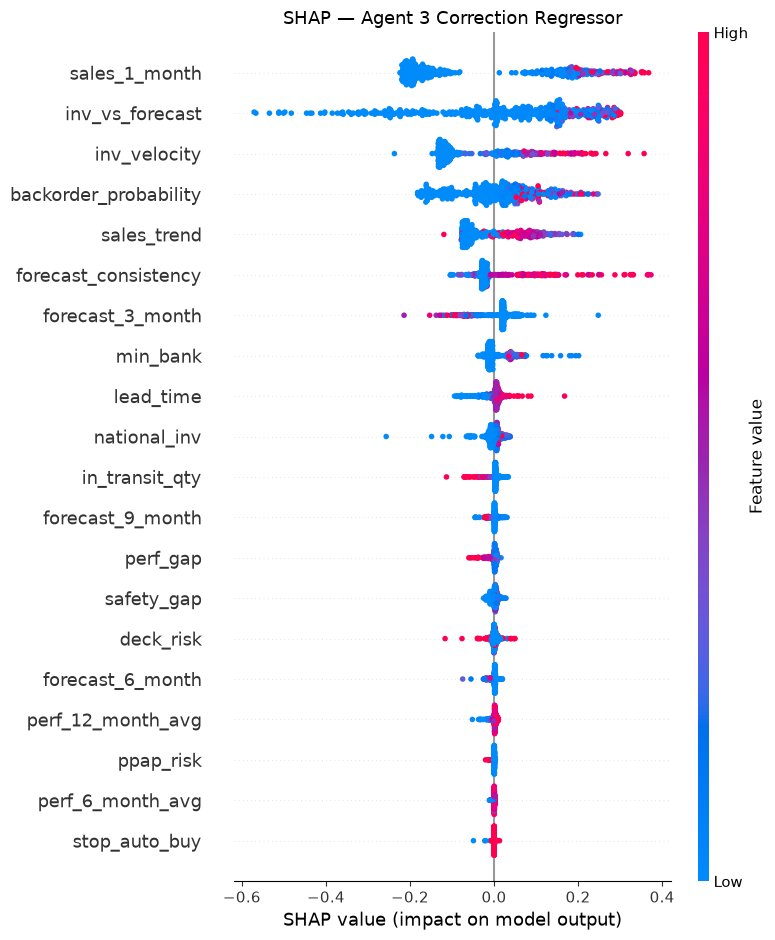

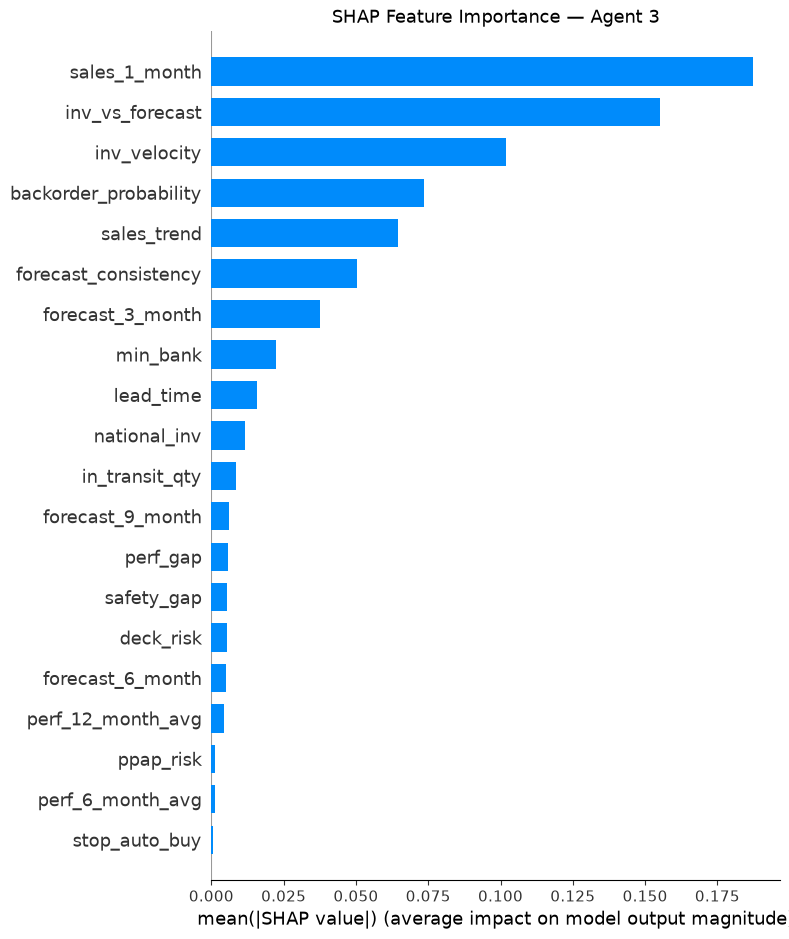

In [17]:
print('Computing SHAP values for Task B (Correction Regressor)...')

X_shap = X_val.iloc[:500]

explainer_b = shap.TreeExplainer(lgb_b)
shap_vals_b = explainer_b.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_b, X_shap, show=False)
plt.title('SHAP \u2014 Agent 3 Correction Regressor', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'agent3_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_b, X_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance \u2014 Agent 3', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'agent3_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---

## STEP 15 — FINAL TEST SET EVALUATION

> Test set touched **once** — state this explicitly in the paper.

In [18]:
print('FINAL EVALUATION ON HELD-OUT TEST SET')
print('(Test set touched for the first time)')

# Task A — dynamically use model selected by comparison table
final_a_probs = final_model_a.predict_proba(X_test)[:, 1]
final_a_preds = (final_a_probs >= final_threshold_a).astype(int)

final_f1  = f1_score(yA_test, final_a_preds, zero_division=0)
final_mcc = matthews_corrcoef(yA_test, final_a_preds)
final_auc = roc_auc_score(yA_test, final_a_probs)
final_pr  = average_precision_score(yA_test, final_a_probs)

print('\n' + '=' * 60)
print(f'  TASK A \u2014 BIAS DETECTOR ({best_a}) \u2014 TEST RESULTS')
print('=' * 60)
print(f'  F1-Score  : {final_f1:.4f}')
print(f'  MCC       : {final_mcc:.4f}')
print(f'  ROC-AUC   : {final_auc:.4f}')
print(f'  PR-AUC    : {final_pr:.4f}')

# Task B — use dynamically selected model
final_b_test_preds = final_model_b.predict(X_test)
final_mae  = mean_absolute_error(yB_test, final_b_test_preds)
final_rmse = root_mean_squared_error(yB_test, final_b_test_preds)
final_r2   = r2_score(yB_test, final_b_test_preds)

print('\n' + '=' * 60)
print(f'  TASK B \u2014 CORRECTION REGRESSOR ({best_b}) \u2014 TEST RESULTS')
print('=' * 60)
print(f'  MAE       : {final_mae:.4f}')
print(f'  RMSE      : {final_rmse:.4f}')
print(f'  R\u00b2        : {final_r2:.4f}')

h_final, a_final, impr_final = compute_mape_improvement(
    final_model_b, X_test, df_agent3.loc[X_test.index],
    f'{best_b} \u2014 TEST SET (Final)'
)

print('\n' + '=' * 60)
print('  AGENT 3 FINAL CONTRIBUTION SUMMARY')
print('=' * 60)
print(f'  Human Planner MAPE  : {h_final:.2f}%')
print(f'  Agent 3 MAPE        : {a_final:.2f}%')
print(f'  Absolute Reduction  : {impr_final:.2f}%  \u2190 report in abstract')
print(f'  Relative Reduction  : {impr_final/h_final*100:.1f}%  \u2190 report in results')
print('=' * 60)

FINAL EVALUATION ON HELD-OUT TEST SET
(Test set touched for the first time)

  TASK A — BIAS DETECTOR (LightGBM) — TEST RESULTS
  F1-Score  : 0.9542
  MCC       : 0.9467
  ROC-AUC   : 0.9986
  PR-AUC    : 0.9908

  TASK B — CORRECTION REGRESSOR (XGBoost) — TEST RESULTS
  MAE       : 0.1617
  RMSE      : 0.2839
  R²        : 0.7388

  [XGBoost — TEST SET (Final)]
  Human  MAPE   : 1867.05%    Human  WMAPE : 62.39%
  Agent3 MAPE   : 723.05%    Agent3 WMAPE : 37.35%
  MAPE  Improv  : 61.3% relative
  WMAPE Improv  : 40.1% relative  ← cite in paper (robust metric)

  AGENT 3 FINAL CONTRIBUTION SUMMARY
  Human Planner MAPE  : 1867.05%
  Agent 3 MAPE        : 723.05%
  Absolute Reduction  : 1144.00%  ← report in abstract
  Relative Reduction  : 61.3%  ← report in results


---

## STEP 16 — AGENT 3 OUTPUT CONTRACT (to Agent 4)

In [19]:
def agent3_predict(product_row, model_a, model_b, threshold_a, feature_cols):
    X_row = product_row[feature_cols].values.reshape(1, -1)

    bias_prob = model_a.predict_proba(X_row)[0, 1]
    bias_flag = int(bias_prob >= threshold_a)
    cf        = float(model_b.predict(X_row)[0])

    risk_suppressed = bool(product_row.get('alarm_triggered', 0) == 1)
    if risk_suppressed:
        cf = 1.0

    human_forecast    = float(product_row['forecast_3_month'])
    adjusted_forecast = human_forecast * cf

    if cf < 0.90:   rec = 'REDUCE_PLAN'
    elif cf > 1.10: rec = 'INCREASE_PLAN'
    else:           rec = 'HOLD'

    return {
        'product_id'           : str(product_row.get('product_id', 'unknown')),
        'human_forecast_3m'    : round(human_forecast, 2),
        'adjusted_forecast_3m' : round(adjusted_forecast, 2),
        'correction_factor'    : round(cf, 4),
        'bias_detected'        : bool(bias_flag),
        'bias_probability'     : round(float(bias_prob), 4),
        'bias_severity'        : 'SEVERE' if cf < 0.75 else
                                  'MILD'   if cf < 0.90 else 'NONE',
        'risk_override_applied': risk_suppressed,
        'agent2_alarm'         : bool(product_row.get('alarm_triggered', 0)),
        'agent2_backorder_prob': round(float(product_row.get(
                                       'backorder_probability', 0)), 4),
        'recommendation'       : rec,
    }


print('\u2705 Agent 3 output contract defined')
print('   Output feeds directly to Agent 4 (Replenishment)')

✅ Agent 3 output contract defined
   Output feeds directly to Agent 4 (Replenishment)


---

## STEP 17 — SAVE ALL MODELS

In [20]:
FORECAST_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Task A
joblib.dump(lgb_a, FORECAST_MODELS_DIR / 'agent3_bias_detector_lgbm.pkl')
joblib.dump(cat_a, FORECAST_MODELS_DIR / 'agent3_bias_detector_catboost.pkl')
joblib.dump(brf_a, FORECAST_MODELS_DIR / 'agent3_bias_detector_brf.pkl')

# Task B
joblib.dump(xgb_b, FORECAST_MODELS_DIR / 'agent3_corrector_xgb.pkl')
joblib.dump(lgb_b, FORECAST_MODELS_DIR / 'agent3_corrector_lgbm.pkl')
joblib.dump(cat_b, FORECAST_MODELS_DIR / 'agent3_corrector_catboost.pkl')

# Metadata
joblib.dump(FEATURE_COLS, FORECAST_MODELS_DIR / 'agent3_feature_cols.pkl')
joblib.dump({
    'lgbm_a'                : float(best_t_lgb_a),
    'catboost_a'            : float(best_t_cat_a),
    'brf_a'                 : float(best_t_brf_a),
    'overestimate_threshold': OVERESTIMATE_THRESHOLD,
    'selected_model_a'      : best_a,
    'selected_threshold_a'  : float(final_threshold_a),
}, FORECAST_MODELS_DIR / 'agent3_thresholds.pkl')
joblib.dump({
    'human_mape_3m'     : HUMAN_MAPE_3M,
    'human_wmape_3m'    : HUMAN_WMAPE_3M,
    'agent3_mape_final' : a_final,
    'mape_improvement'  : impr_final,
}, FORECAST_MODELS_DIR / 'agent3_business_metrics.pkl')

print('✅ All Agent 3 (Forecast Optimizer) models saved to:')
print(f'   {FORECAST_MODELS_DIR}')
for f in sorted(FORECAST_MODELS_DIR.glob('agent3_*.pkl')):
    print(f'   {f.name}  ({f.stat().st_size/1e6:.2f} MB)')

✅ All Agent 3 (Forecast Optimizer) models saved to:
   E:\CSE499B\Project Codes\Forcast Optimizer Model\forecast models
   agent3_bias_detector_brf.pkl  (3738.29 MB)
   agent3_bias_detector_catboost.pkl  (2.35 MB)
   agent3_bias_detector_lgbm.pkl  (1.79 MB)
   agent3_business_metrics.pkl  (0.00 MB)
   agent3_corrector_catboost.pkl  (2.31 MB)
   agent3_corrector_lgbm.pkl  (3.23 MB)
   agent3_corrector_xgb.pkl  (4.96 MB)
   agent3_feature_cols.pkl  (0.00 MB)
   agent3_thresholds.pkl  (0.00 MB)
